# (08) Dream: Rot MNIST

host = ```mach```, device = ```cuda:2```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## anim setup

In [3]:
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/hallucinate')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[]

## Local helper functions

In [4]:
from analysis.final import perform_analysis, get_root_path

root = get_root_path()


def _quick_xtract_ftr_with_recons(t_total, d_theta=None, data_batch_sz=13):
    if d_theta is None:
        data = 'vld'
    else:
        data = tr.get_feeder(
            data='vld',
            data_batch_sz=data_batch_sz,
            max_delta_theta=d_theta,
            sample_uniform=False,
            theta_0=0,
        )[0]
        data.set_current_delta_theta(d_theta)

    output = tr.xtract_ftr(
        data=data,
        t_total=t_total,
        save_freq=1,
        data_batch_sz=data_batch_sz,
        n_data_batches=1,
        return_recon=True,
        verbose=False,
    )
    return output


def _quick_show_evolution_side_by_side(time_range, sample_i=0):
    x2p = np.concatenate([
        output['true'][sample_i, time_range],
        output['recon'][sample_i, time_range],
    ])
    plot_weights(x2p, nrows=2, method='min-max')
    plt.show()

## Load model (MNIST)

In [6]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)', 'fwd-(3,7)']
fits = get_list_of_fits(patterns)
print(fits)

['poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_08,18:47)']

In [7]:
# # a = 'poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>'
# # b = 'b200-ep200-lr(0.001)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_26,10:47)'

# a = 'poisson_MNIST+rotate_t-(32,32)_b-8_kms-(192,8,3)_fwd-(3,7)_prob_<ngd|lin>'
# b = 'b100-ep200-lr(0.0005)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_29,09:02)'

# tr, meta = load_model(pjoin(a, b), device=device)
# meta['checkpoint']

fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_08,18:47)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

100

In [8]:
layer = tr.model.layer

In [9]:
tr.print()

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_<ngd|lin>
b200-ep100-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_08,18:47)

### sanity check

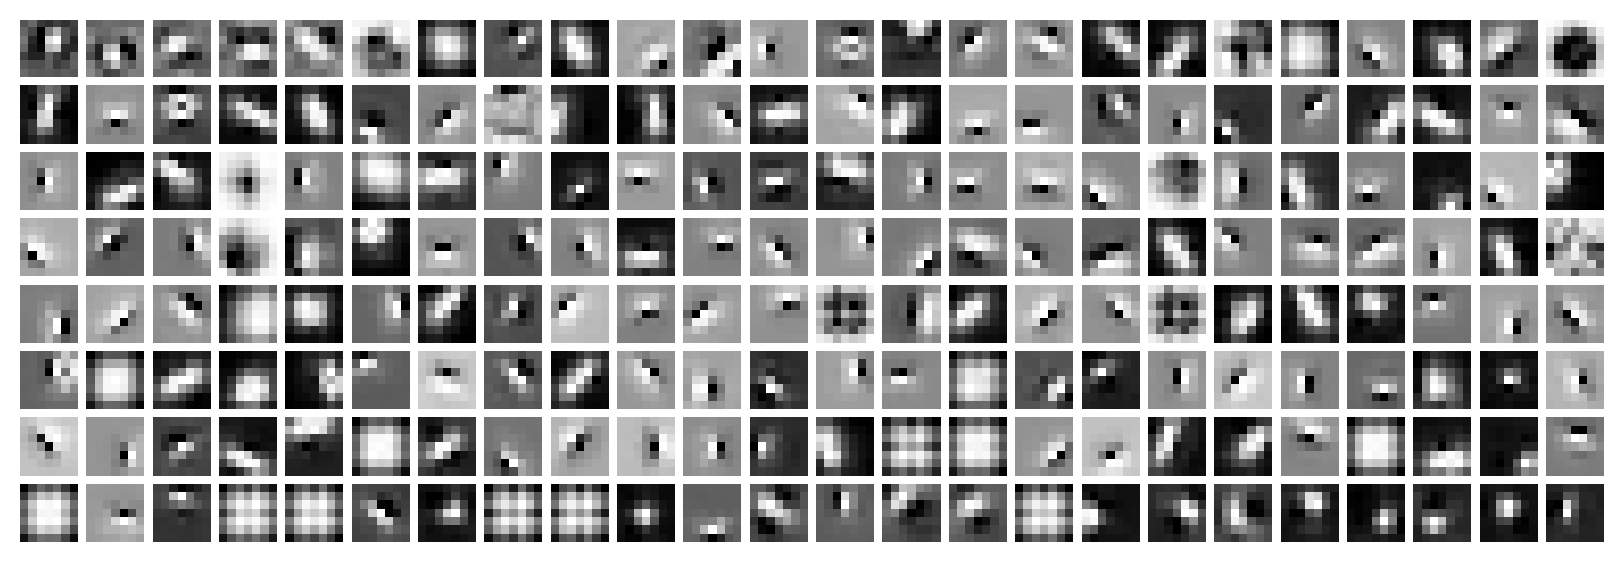

In [10]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [11]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.426
dt_fwd = 1.909

100%|███████████████████████████████████| 2/2 [00:58<00:00, 29.34s/it]


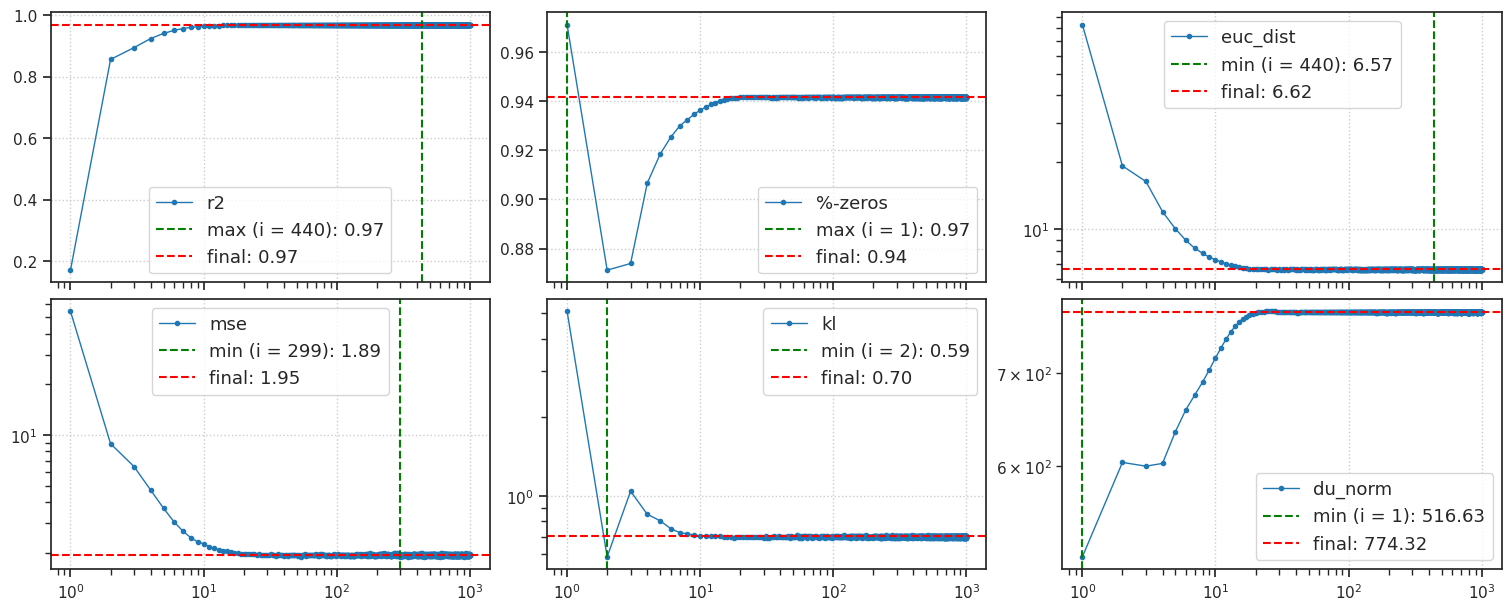

CPU times: user 59.8 s, sys: 511 ms, total: 1min
Wall time: 1min


In [12]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=2)
_ = plot_convergence(results=results, color='C0')

### dream into future

In [13]:
output = _quick_xtract_ftr_with_recons(t_total=40, d_theta=2.0)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

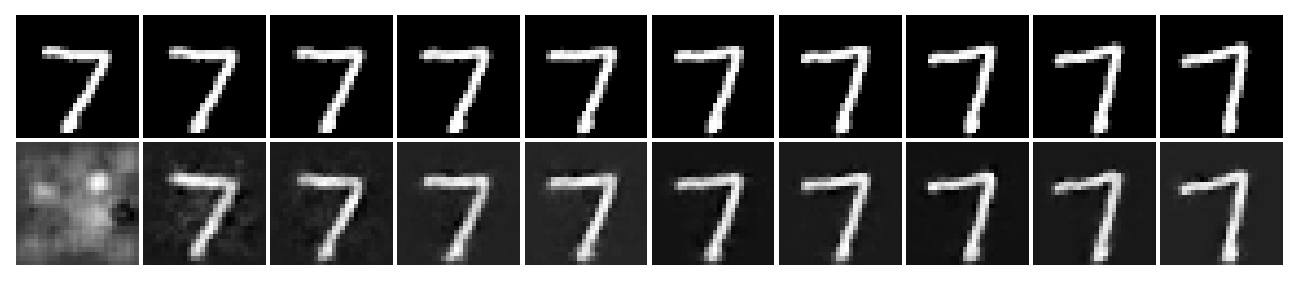

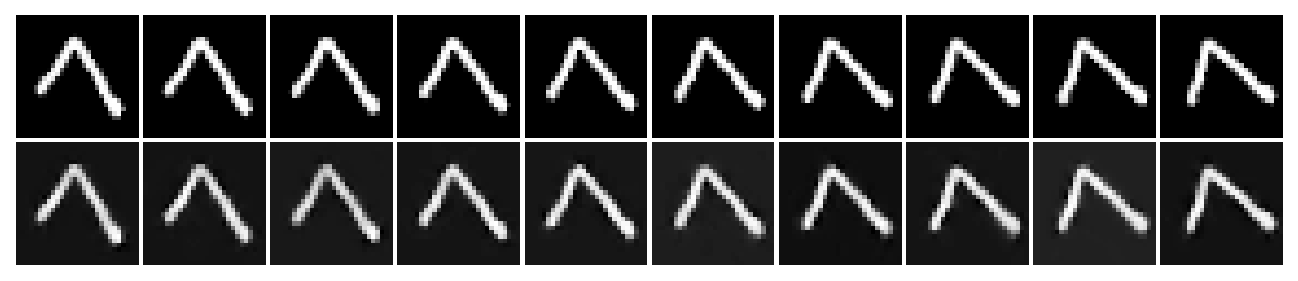

In [14]:
_quick_show_evolution_side_by_side(time_range=range(10))
_quick_show_evolution_side_by_side(time_range=range(30, 40))

In [15]:
layer = tr.model.layer
layer.conditional.loc.shape

torch.Size([13, 1, 28, 28])

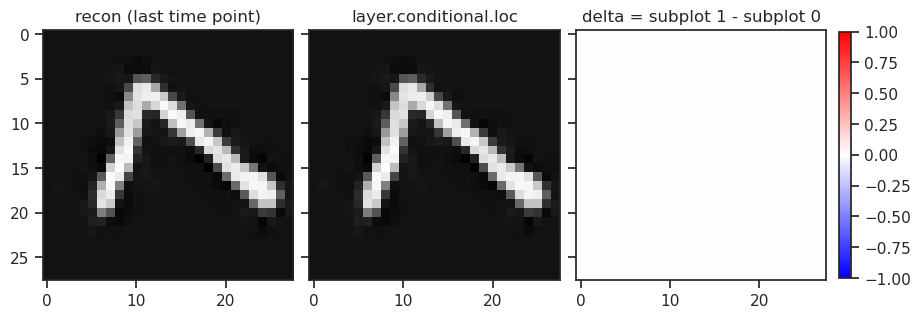

In [16]:
fig, axes = create_figure(1, 3, (9, 3.2), 'all', 'all')

axes[0].imshow(output['recon'][0, -1].squeeze(), cmap='Greys_r')
axes[1].imshow(tonp(layer.conditional.loc[0].squeeze()), cmap='Greys_r')

delta_imag = tonp(layer.conditional.loc[0].squeeze()) - output['recon'][0, -1].squeeze()
im = axes[2].imshow(delta_imag, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[2], shrink=0.8)

axes[0].set_title('recon (last time point)')
axes[1].set_title('layer.conditional.loc')
axes[2].set_title('delta = subplot 1 - subplot 0')

plt.show()

In [17]:
dream_x = []
dream_samples = []

dream_state = []
dream_d_state = []

output = _quick_xtract_ftr_with_recons(t_total=40, d_theta=2.0)

for t in tqdm(range(60)):
    with layer.temporary_temperature(layer.cfg.validation_temp):
        layer.update_generative_state()

    dream_x.append(tonp(layer.conditional.loc))
    dream_samples.append(tonp(layer.samples))
    
    layer.update_predictive_state()
    
    dream_state.append(tonp(layer.state[0]))
    dream_d_state.append(tonp(layer.d_state[0]))

dream_x, dream_samples, dream_state, dream_d_state = stack_map(
    [dream_x, dream_samples, dream_state, dream_d_state], axis=1)

100%|███████████████████████████████████████████| 60/60 [00:00<00:00, 97.85it/s]


In [18]:
from utils.animation import show_movie

show_movie(dream_x[0].squeeze(), vmin=0, vmax=1)

In [19]:
dream_du_norm = np.linalg.norm(flatten_np(dream_d_state, start_dim=2), axis=-1)
dream_du_norm.shape

(13, 60)

In [20]:
dream_du_norm[0]

array([  785.95514,   788.0716 ,   803.33936,   823.34863,   859.1416 ,
         877.1665 ,   903.2672 ,   923.1491 ,   943.3926 ,   950.8366 ,
         987.064  ,  1010.48846,  1032.5933 ,  1173.4895 ,  1397.8086 ,
        2152.6345 ,  3518.5957 ,  5264.453  ,  6951.7603 ,  8707.964  ,
       10345.235  , 11735.197  , 13099.08   , 14230.711  , 15722.218  ,
       16936.404  , 18045.02   , 18750.936  , 19345.385  , 19713.303  ,
       19953.959  , 20136.402  , 20248.734  , 20429.914  , 20446.506  ,
       20612.24   , 20576.498  , 20545.896  , 20554.012  , 20650.043  ,
       20777.613  , 20708.95   , 20673.586  , 20595.133  , 20681.7    ,
       20693.695  , 20609.754  , 20645.396  , 20646.826  , 20559.139  ,
       20666.02   , 20651.342  , 20691.82   , 20665.277  , 20566.533  ,
       20619.395  , 20742.033  , 20800.05   , 20798.082  , 20739.885  ],
      dtype=float32)

<Axes: ylabel='Count'>

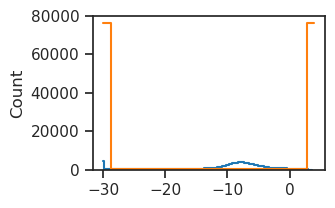

In [21]:
histplot(dream_state[:, 0].ravel())
histplot(dream_state[:, -1].ravel())

In [22]:
dream_x = []
dream_samples = []

dream_state = []
dream_d_state = []

output = _quick_xtract_ftr_with_recons(t_total=40, d_theta=2.0)

x = torch.zeros((13, 1, 28, 28))
x = tr.feeder_trn.to(x)

for t in tqdm(range(60)):
    with layer.temporary_temperature(layer.cfg.validation_temp):
        layer.update_generative_state()

    dream_x.append(tonp(layer.conditional.loc))
    dream_samples.append(tonp(layer.samples))
    
    du = layer.encode(x)
    layer.update_state(du)
    
    layer.update_predictive_state()
    
    dream_state.append(tonp(layer.state[0]))
    dream_d_state.append(tonp(layer.d_state[0]))

dream_x, dream_samples, dream_state, dream_d_state = stack_map(
    [dream_x, dream_samples, dream_state, dream_d_state], axis=1)

100%|██████████████████████████████████████████| 60/60 [00:00<00:00, 105.51it/s]


In [23]:
from utils.animation import show_movie

show_movie(dream_x[0].squeeze(), vmin=0, vmax=1)

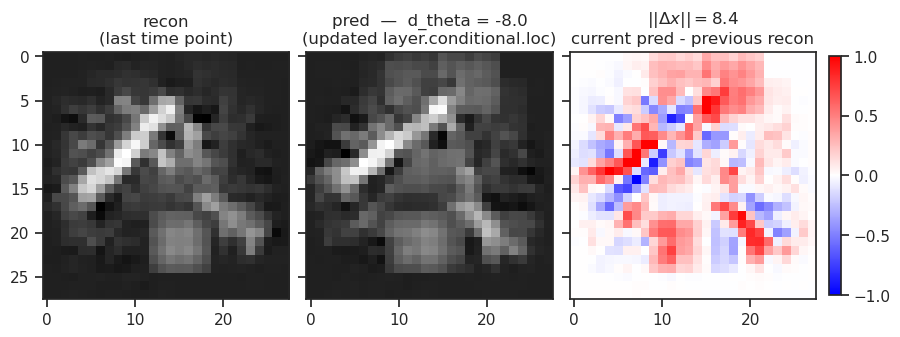

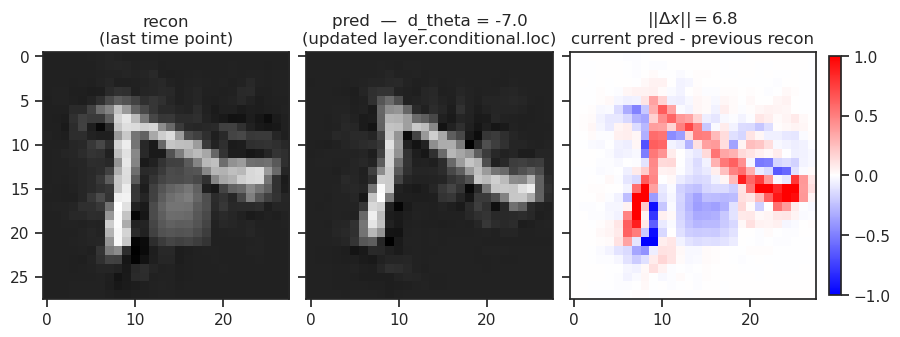

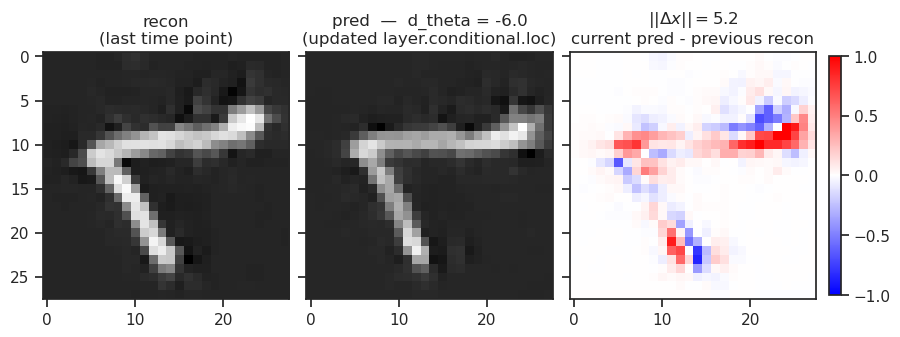

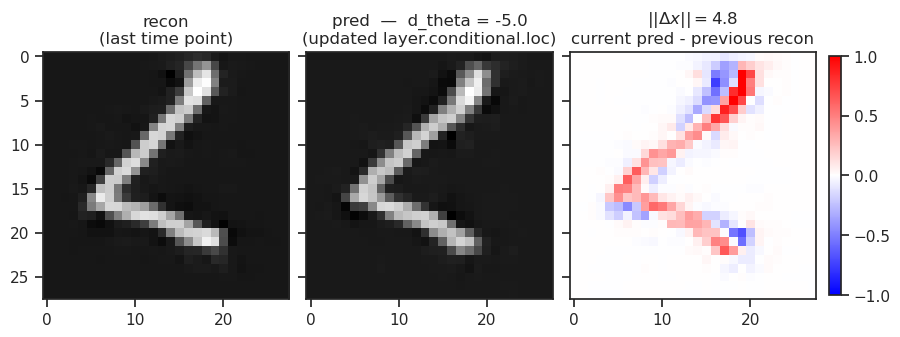

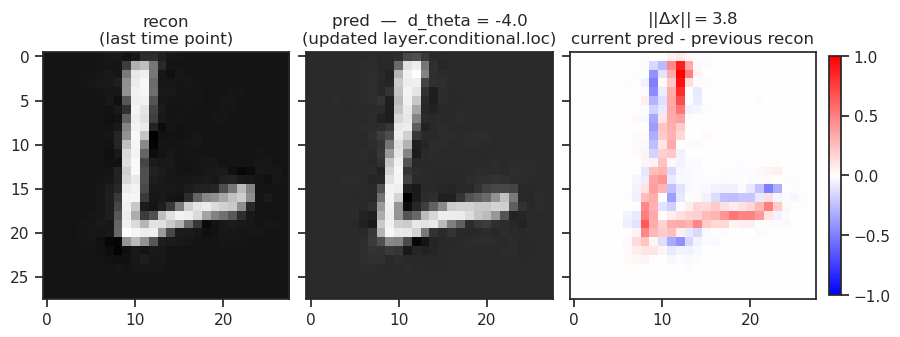

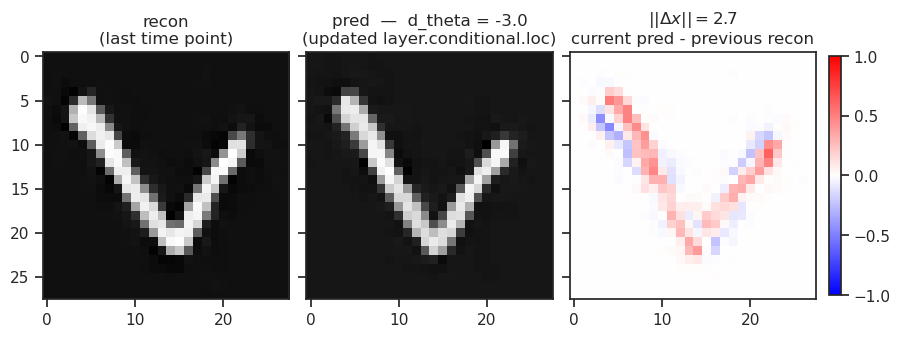

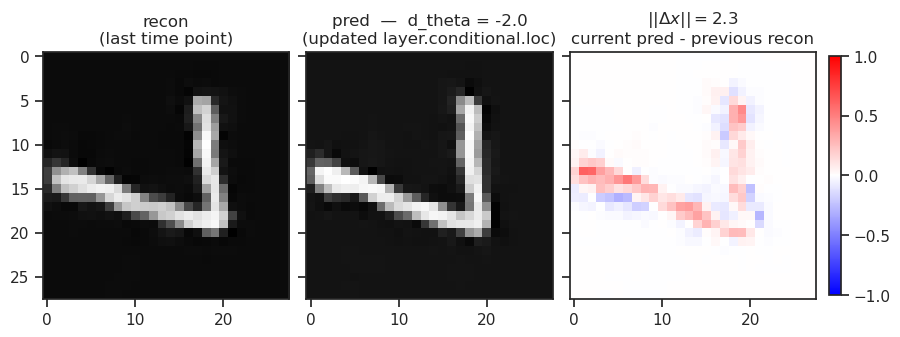

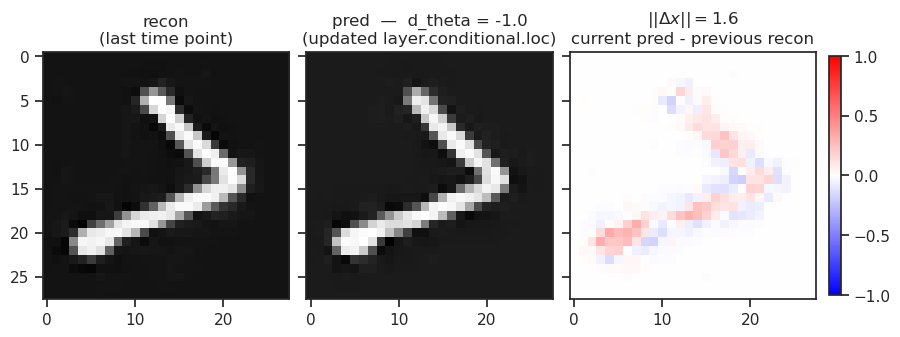

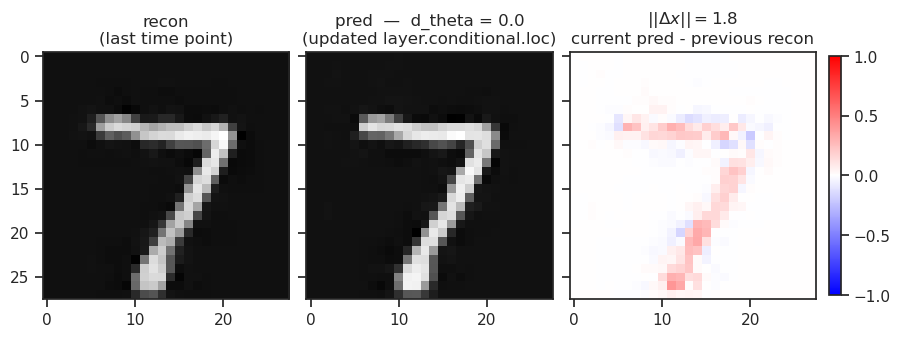

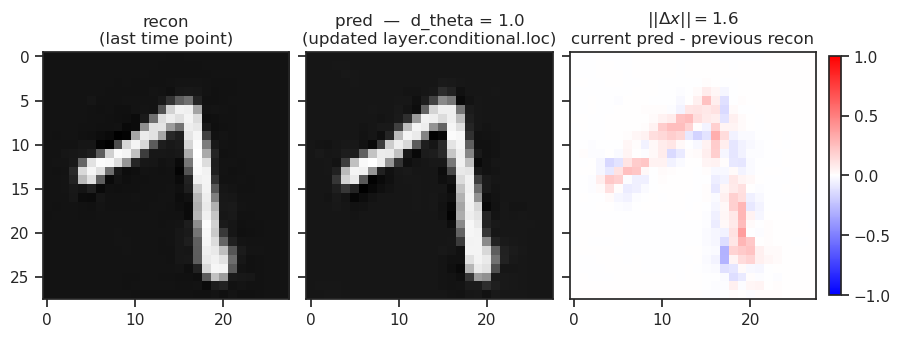

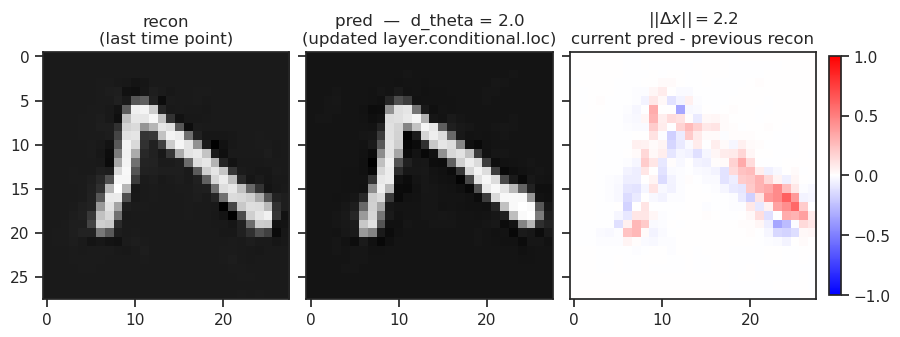

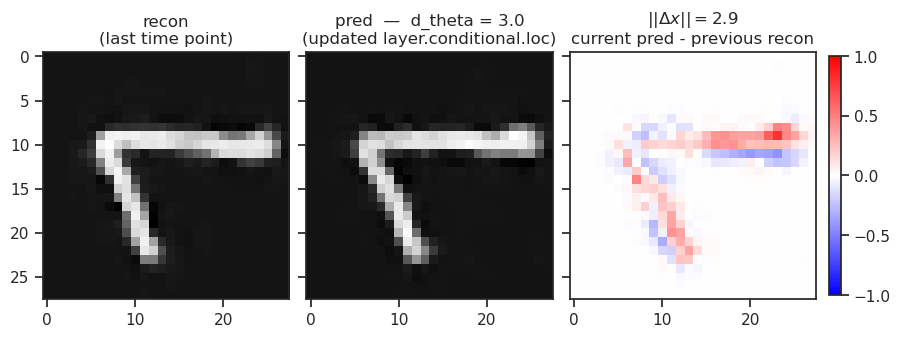

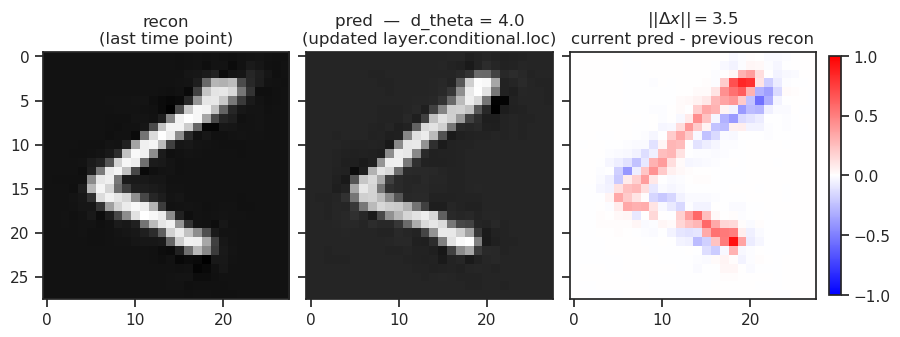

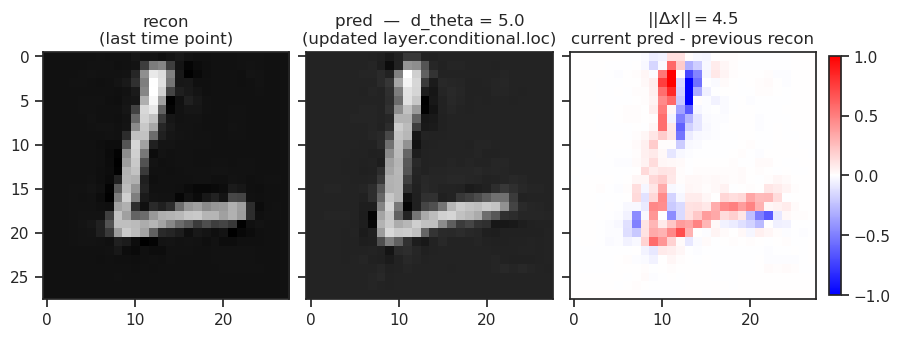

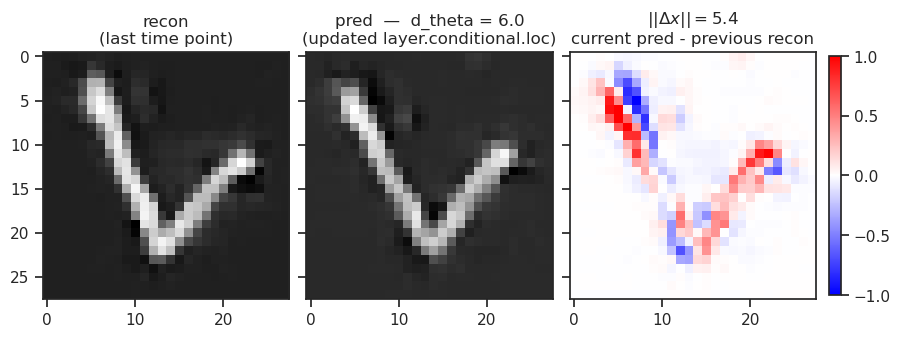

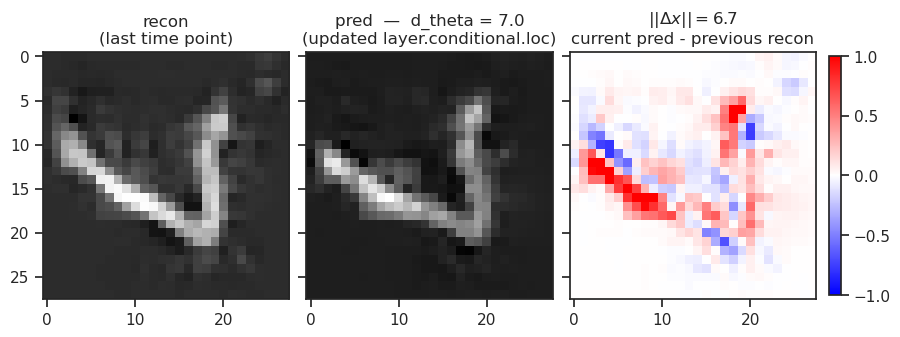

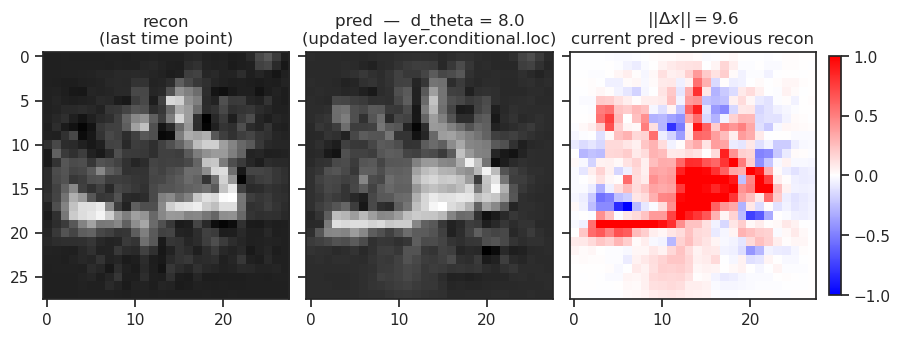

In [38]:
delta_img_norms = {}

for d_theta in np.linspace(-8.0, 8.0, 17):

    output = _quick_xtract_ftr_with_recons(t_total=40, d_theta=d_theta)

    with layer.temporary_temperature(layer.cfg.validation_temp):
        layer.update_generative_state()
        
    fig, axes = create_figure(1, 3, (9, 3.2), 'all', 'all')

    axes[0].imshow(output['recon'][0, -1].squeeze(), cmap='Greys_r')
    axes[1].imshow(tonp(layer.conditional.loc[0].squeeze()), cmap='Greys_r')

    delta_img = tonp(layer.conditional.loc[0].squeeze()) - output['recon'][0, -1].squeeze()
    im = axes[2].imshow(delta_img, cmap='bwr', vmin=-1, vmax=1)
    plt.colorbar(im, ax=axes[2], shrink=0.88)
    
    delta_img_norm = sp_lin.norm(delta_img)
    delta_img_norms[d_theta] = delta_img_norm

    axes[0].set_title('recon\n(last time point)')
    axes[1].set_title(f"pred  —  d_theta = {d_theta:0.1f}\n(updated layer.conditional.loc)")
    axes[2].set_title(r"$||\Delta x|| = $" + f"{delta_img_norm:0.1f}\ncurrent pred - previous recon")

    plt.show()

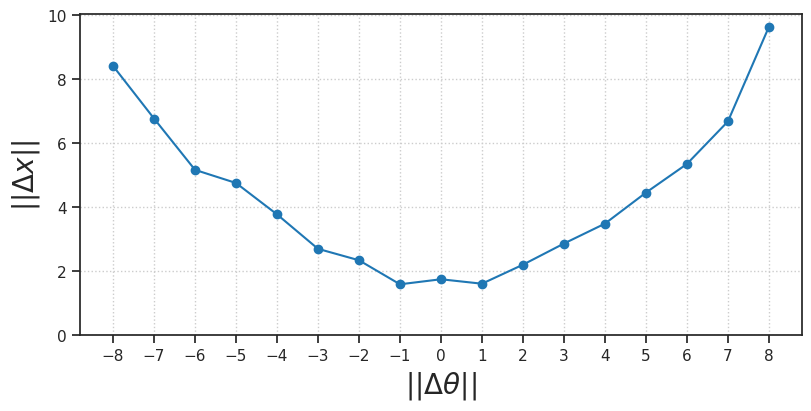

In [58]:
fig, ax = create_figure(1, 1, (8, 4))
ax.plot(delta_img_norms.keys(), delta_img_norms.values(), marker='o')
ax.locator_params(axis='x', nbins=20)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$||\Delta \theta||$", fontsize=20)
ax.set_ylabel(r"$||\Delta x||$", fontsize=20)
add_grid(ax)
plt.show()